**MACHINE LEARNING 23CSE301 LAB ACTIVITY 4 SUPPORT VECTOR MACHINES EXCERCISE 1**

ROHITH SUBRAMANIAN NITHYADEVI CH.SC.U4CSE24141

**Q1.** Generate a random dataset and that follows a quadratic distribution using SVM.

**Dataset:** Synthetically generated in this notebook (points labelled by a quadratic boundary), following the same programming approach used in Section 8.5 of the Lab Activity Book (Implementing SVM using Python).

### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

### Generating a Random Dataset that follows a Quadratic Distribution

In [2]:
np.random.seed(0)
n = 400

x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-2, 10, n)

# label = 1 if the point lies above the parabola x2 = x1^2 (plus a little noise), else 0
noise = np.random.normal(0, 0.5, n)
label = (x2 > (x1**2 + noise)).astype(int)

data = pd.DataFrame({'x1': x1, 'x2': x2, 'label': label})
print(data.shape)
data.head()

(400, 3)


,x1,x2,label
0,0.292881,2.815114,1
1,1.291136,9.151497,1
2,0.616580,-0.804621,0
3,0.269299,9.343618,1
4,-0.458071,8.433862,1


### Checking for any null values in dataset

In [3]:
data.isnull().sum()

x1       0
x2       0
label    0
dtype: int64

### Assigning Dependent and Independent Variables

In [4]:
x = data[['x1', 'x2']]
y = data['label']

### Splitting the dataset into Training and Testing Dataset

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
     test_size=0.3, random_state=5)
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(280, 2)

(280,)

(120, 2)

(120,)

### Preprocessing Data with StandardScaler

In [6]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Fitting the Model (SVM) using 'rbf' kernel (needed since the boundary is quadratic, i.e. non-linear)

In [7]:
model = SVC(kernel='rbf', random_state=0)
model.fit(x_train, y_train)
svc_prediction = model.predict(x_test)
print('svc_prediction: ', svc_prediction)

svc_prediction:  [1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 0
 1 1 1 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0
 0 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 1 1 1
 1 1 0 0 1 1 1 1 1]


### Evaluation Metrics for 'rbf' kernel

In [8]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)
print('SVC [ kernel - rbf ]')
print('Confusion Matrix : \n', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100), '%')
print(classification_report(svc_prediction, y_test))

SVC [ kernel - rbf ]
Confusion Matrix : 
 [[48  3]
 [ 2 67]]
Accuracy Score :  0.9583333333333334
Accuracy in Percentage :  95 %
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        50
           1       0.97      0.96      0.96        70

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



[Text(0.5, 1.0, 'SVC [rbf] on Quadratic Data')]

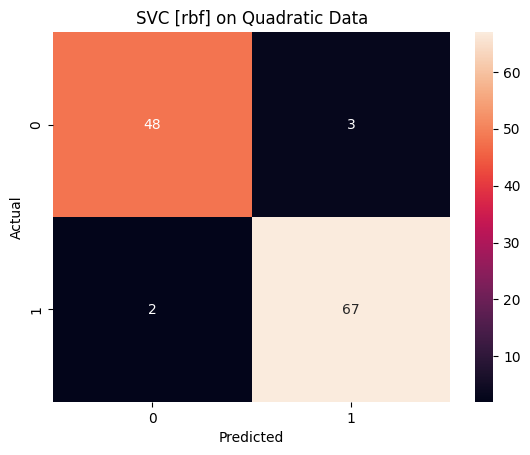

In [9]:
conf_mat = pd.crosstab(y_test, svc_prediction, rownames=['Actual'],
     colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='SVC [rbf] on Quadratic Data')

### Visualizing the Quadratic Data and the SVM Decision Boundary

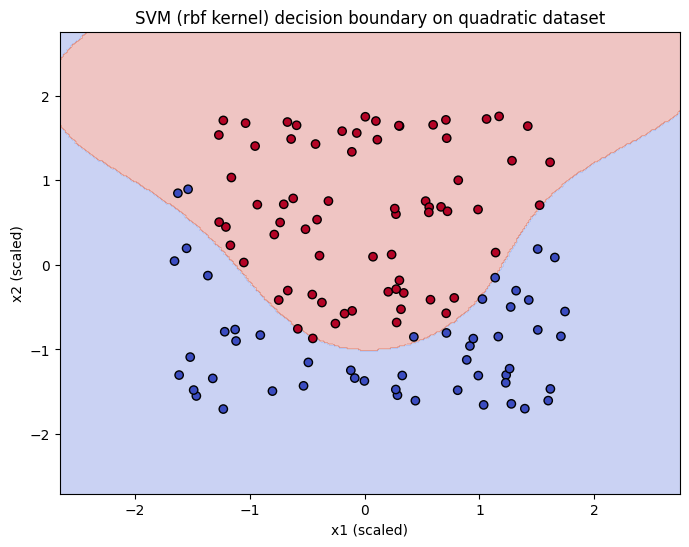

In [10]:
xx, yy = np.meshgrid(np.linspace(x_test[:,0].min()-1, x_test[:,0].max()+1, 300),
                      np.linspace(x_test[:,1].min()-1, x_test[:,1].max()+1, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title('SVM (rbf kernel) decision boundary on quadratic dataset')
plt.xlabel('x1 (scaled)')
plt.ylabel('x2 (scaled)')
plt.show()